In [ ]:
import pandas as pd
import sys 
from reusable import label_Encoder,oneHot_encoder,cleaning

import matplotlib.pyplot as plt
import seaborn as sns

health = pd.read_csv('insurance.csv')

df = pd.DataFrame(health)



df = oneHot_encoder(df)
df = label_Encoder(df) 
df = cleaning(df)

def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi >= 18.5 and bmi <= 24.9:   
        return 'normal'   
    elif bmi  >= 25 and bmi <= 29.9:
        return 'overweight'
    elif bmi >= 30:
        return 'obese' 

df['bmi_category'] = df['bmi'].apply(bmi_category)  

# print(df)
"""
apply() is a process of reading each value from a column
one by one and passing it into a function which we wrote manually
and collecting the returned result from our function and pass it into a new column
without touching the original column
"""

      age  sex     bmi  children  smoker      charges  region_northwest  \
0      19    0  27.900         0       1  16884.92400                 0   
1      18    1  33.770         1       0   1725.55230                 0   
2      28    1  33.000         3       0   4449.46200                 0   
3      33    1  22.705         0       0  21984.47061                 1   
4      32    1  28.880         0       0   3866.85520                 1   
...   ...  ...     ...       ...     ...          ...               ...   
1333   50    1  30.970         3       0  10600.54830                 1   
1334   18    0  31.920         0       0   2205.98080                 0   
1335   18    0  36.850         0       0   1629.83350                 0   
1336   21    0  25.800         0       0   2007.94500                 0   
1337   61    0  29.070         0       1  29141.36030                 1   

      region_southeast  region_southwest bmi_category  
0                    0                 1   

'\napply() is a process of reading each value from a column\none by one and passing it into a function which we wrote manually\nand collecting the returned result from our function and pass it into a new column\nwithout touching the original column\n'

In [9]:
# df = df.drop(['obese', 'overweight', 'underweight','normal'],axis=1)
if 'bmi_category' in df.columns:
    encoding = pd.get_dummies(df['bmi_category'], drop_first=True,dtype=int)
    df = pd.concat([df,encoding],axis=1)
    # df = df.drop(columns=['bmi_category'])




In [10]:
print(df['bmi_category'])

0       overweight
1            obese
2            obese
3           normal
4       overweight
           ...    
1333         obese
1334         obese
1335         obese
1336    overweight
1337    overweight
Name: bmi_category, Length: 1337, dtype: object


In [3]:
print(df[['age','sex','bmi','children','smoker','charges','region_northwest', 'region_southeast', 'region_southwest']].corr())

                       age       sex       bmi  children    smoker   charges  \
age               1.000000 -0.019814  0.109344  0.041536 -0.025587  0.298308   
sex              -0.019814  1.000000  0.046397  0.017848  0.076596  0.058044   
bmi               0.109344  0.046397  1.000000  0.012755  0.003746  0.198401   
children          0.041536  0.017848  0.012755  1.000000  0.007331  0.067389   
smoker           -0.025587  0.076596  0.003746  0.007331  1.000000  0.787234   
charges           0.298308  0.058044  0.198401  0.067389  0.787234  1.000000   
region_northwest  0.001495 -0.012482 -0.136138  0.026044 -0.036321 -0.038695   
region_southeast -0.012311  0.017578  0.270057 -0.023492  0.068282  0.073578   
region_southwest  0.009415 -0.003767 -0.006211  0.021538 -0.037168 -0.043637   

                  region_northwest  region_southeast  region_southwest  
age                       0.001495         -0.012311          0.009415  
sex                      -0.012482          0.017578 

In [3]:
df['high_risks'] = ((df['smoker'] == 1) & (df['bmi'] > 30)).astype(int)
df
# df['high_risks'].sample(30)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,obese,overweight,underweight,high_risks
0,19,0,27.900,0,1,16884.92400,0,0,1,0,1,0,0
1,18,1,33.770,1,0,1725.55230,0,1,0,1,0,0,0
2,28,1,33.000,3,0,4449.46200,0,1,0,1,0,0,0
3,33,1,22.705,0,0,21984.47061,1,0,0,0,0,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0,1,0,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0,1,0,0,0
1336,21,0,25.800,0,0,2007.94500,0,0,1,0,1,0,0


'we can see a clear ( class imbalance ) - where one class has high value difference from another class value'

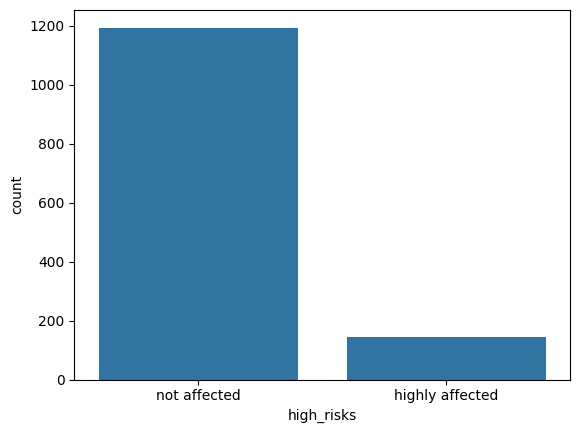

In [5]:
sns.countplot(data=df, x=df['high_risks'])
plt.xticks([0,1],labels=['not affected','highly affected'])

"""we can see a clear ( class imbalance ) - where one class has high value difference from another class value"""

In [6]:
df.shape

(1337, 13)